In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

In [2]:
df = pd.read_csv("sentiment_dataset.csv")

In [3]:
print(df.head())

   post_id  user_type                                        review_text  \
0        1    student  This is the worst thing ever, very bad and dis...   
1        2    fitness  I absolutely love this experience, it is amazi...   
2        3    student  I absolutely love this experience, it is amazi...   
3        4  developer  I absolutely love this experience, it is amazi...   
4        5    student  This is the worst thing ever, very bad and dis...   

   likes  
0    450  
1    344  
2    276  
3    446  
4    249  


In [4]:
# remove nulls
df = df.dropna(subset=['review_text'])

# remove duplicates
df = df.drop_duplicates()

# clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df['clean_text'] = df['review_text'].apply(clean_text)

**🤚🏻PART ONE: SENTIMENT ANALYSIS**

In [5]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['polarity'] = df['clean_text'].apply(get_sentiment)

In [6]:
def classify(p):
    if p > 0:
        return "positive"
    elif p < 0:
        return "negative"
    else:
        return "neutral"

df['sentiment'] = df['polarity'].apply(classify)

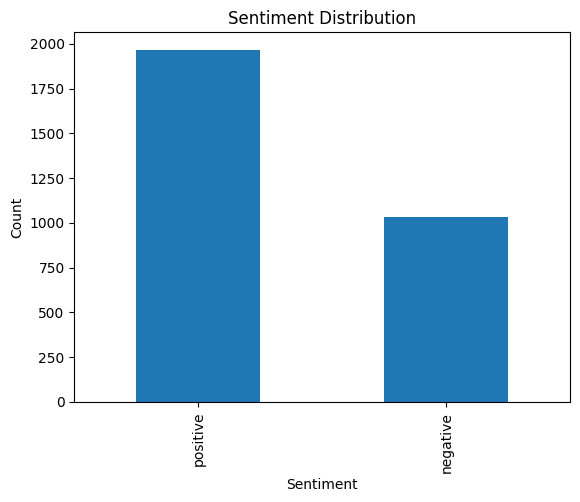

In [7]:
sent_counts = df['sentiment'].value_counts()

plt.figure()
sent_counts.plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

**🦁PART TWO: KEYWORD ANALYSIS**

In [12]:
stop_words = set(stopwords.words('english'))

word_counts  = df['clean_text'].str.split().explode().loc[lambda x: ~x.isin(stop_words)].value_counts()
print(word_counts.head(10))

clean_text
experience       1966
worth            1169
ever             1034
bad              1034
disappointing    1034
thing            1034
worst            1034
okay              989
nothing           989
special           989
Name: count, dtype: int64


In [ ]:
vectorizer = TfidfVectorizer(max_features=10)

X = vectorizer.fit_transform(df['no_stop'])

print(vectorizer.get_feature_names_out())

['bad' 'disappointing' 'ever' 'experience' 'nothing' 'okay' 'special'
 'thing' 'worst' 'worth']


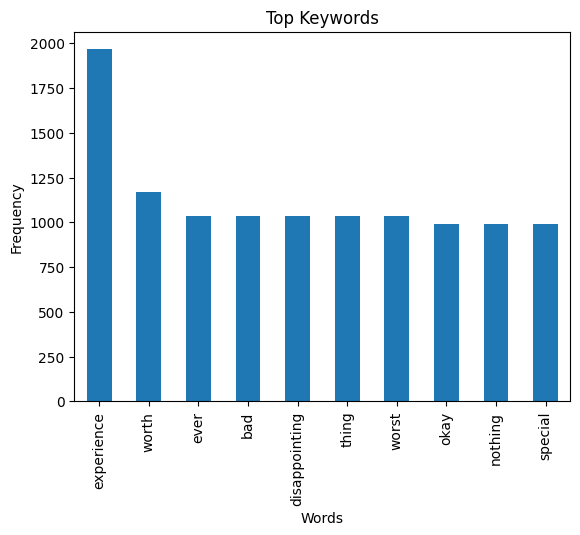

In [11]:
top_words = word_counts.head(10)

plt.figure()
top_words.plot(kind='bar')

plt.title("Top Keywords")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()